In [1]:
import sys
import numpy as np
import anndata as ad

import src as scit
import anndata as ad

/home/aleksander-work/Skrivbord/pyproject/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
adata = ad.read_h5ad('private/data/glue/atac_2025_FULL.h5ad')
adata

AnnData object with n_obs × n_vars = 110289 × 26779
    obs: 'leiden', 'exclude', 'balancing_weight', 'mode', 'label', 'leiden_fix', 'leiden_fix2', 'label_own', 'age', 'time_step', 'time_step_label'
    var: 'chr', 'start', 'end', 'connected', 'chrom', 'chromStart', 'chromEnd'
    uns: 'NN_time_colors', '__scglue__', 'cell_colors', 'colors_dict', 'label_colors', 'leiden', 'leiden_colors', 'neighbors', 'spectral_eigenvalue', 'sum_atac_time_step_label', 'umap'
    obsm: 'X_coarse_landscape', 'X_diffmap', 'X_glue', 'X_glue_RNA', 'X_landscape', 'X_umap'
    varm: 'X_glue'
    layers: 'atac'
    obsp: 'connectivities', 'distances'

In [3]:
adata = adata[adata.obs['age'] > 14].copy()

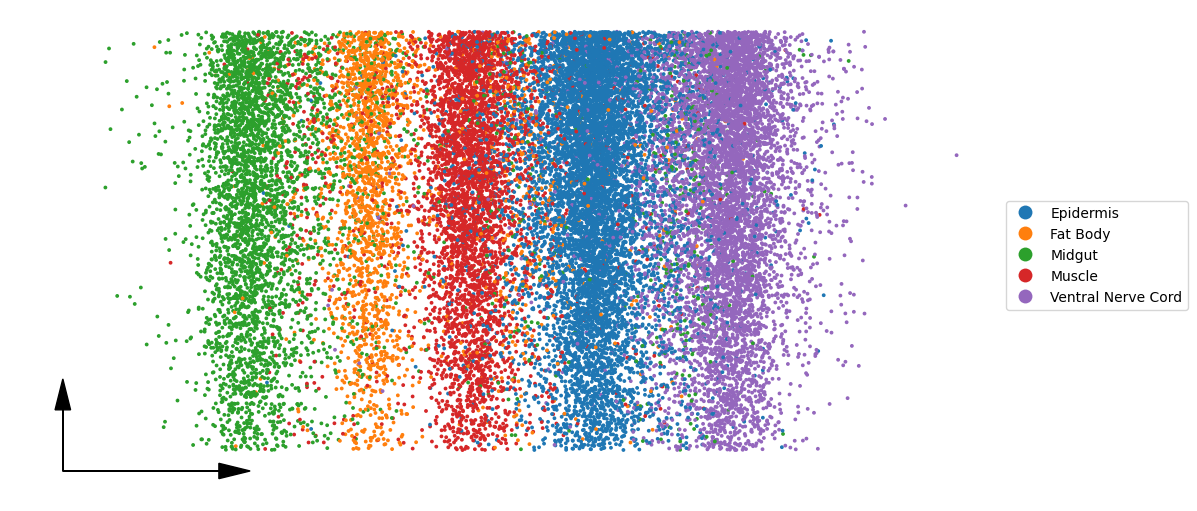

In [4]:
scit.pl.embedding2d(adata, 'X_landscape', 'label_own')

In [5]:
adata.obs

,leiden,exclude,balancing_weight,mode,label,leiden_fix,leiden_fix2,label_own,age,time_step,time_step_label
AACGTACCATGGCAACCTTCCGTCAGTCAACTCAATGGTC,62,False,0.849820,ATAC,Epidermis,9,5,Epidermis,15.637068,10,40
AACGTACCATGGCGGATACCGCGCCTAGTTTGGAGAACGA,24,False,2.027189,ATAC,Glia,3,7,Fat Body,14.804556,9,19
AACGTACCATGTACCTGAATGGCAGCAGTTAATAAGGCTC,26,False,0.899876,ATAC,Somatic muscle,5,7,Muscle,14.609717,9,29
AACTGCTAAGATATCTTCCGCTGATCAGAGTTCTGCAAGA,22,False,0.715977,ATAC,Brain,0,0,Muscle,14.272493,8,28
AACTGCTAAGGAGACGTTCTGGCAGCAGTTCTATCCAACC,49,False,0.567847,ATAC,Ventral nerve cord,7,8,Ventral Nerve Cord,14.072510,8,48
...,...,...,...,...,...,...,...,...,...,...,...
TTGGTTGGTATCGGAGTATGGGCATAACCGGCCATAGAGT,67,False,0.758237,ATAC,PNS & sense,11,9,Ventral Nerve Cord,14.623470,9,49
TTGGTTGGTATGCGGCCTGGACTCGGCATAAACTCTACCA,37,False,0.758237,ATAC,Head ectoderm,3,10,Fat Body,15.509007,10,20
TTGGTTGGTATGCGGCCTGGACTCGGCATAGTTACTACCA,65,False,0.849820,ATAC,Head ectoderm,9,5,Epidermis,15.406718,10,40
TTGGTTGGTATTCCATTCTTTCTCATTGCCATATGACGAC,64,False,0.849820,ATAC,Pharnyx,9,5,Epidermis,15.688938,10,40


In [6]:
scit.ld.fragments_to_bulks(
    adata,
    'label_own',
    'exp1_hrs12-16_b1.fragments.txt',
    'private/data/imp2025/atac_blk/',
    list(scit.tl.get_genome_dict('DM6').keys()),
    #override_names=[a[:-2] for a in adata.obs_names],
    batch_size=10000,
    #parquet_temp='private/data/imp2025/atac_blk/parquet',
    overwrite_output=True
)

Info: Writing to private/data/imp2025/atac_blk/(/)<categorical>.tsv
Info: Loading lazy...
Info: Categoricals: ['Epidermis' 'Fat Body' 'Midgut' 'Muscle' 'Ventral Nerve Cord']
Info: Reading fragments file with 684536669 lines...
Info: Done loading
Info: Number of unique barcodes is 7381787...


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2689/2689 [02:42<00:00, 16.52it/s]
